In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [2]:
class TankEnv(gym.Env):
    def __init__(self, grid_size=10):
        super().__init__()
        self.grid_size = grid_size
        self.action_space = gym.spaces.Discrete(4)
        
        self.n_angles = 4
        self.n_rel_angles = 4
        self.n_dist_bins = 3
        self.n_states = (grid_size**2) * self.n_angles * self.n_rel_angles * self.n_dist_bins
        self.observation_space = gym.spaces.Discrete(self.n_states)
        
        self.obstacles = set()
        self._generate_obstacles(ratio=0.15)
        self.max_steps = 100

    def _generate_obstacles(self, ratio):
        num_obs = int(self.grid_size**2 * ratio)
        self.obstacles = set(np.random.choice(self.grid_size**2, num_obs, replace=False))
        self.obstacles.discard(0)
        self.obstacles.discard(self.grid_size**2 - 1)

    def _pos_to_xy(self, pos): return pos % self.grid_size, pos // self.grid_size
    def _xy_to_pos(self, x, y): return y * self.grid_size + x

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        rng = np.random.default_rng(seed)
        while True:
            self.tank_pos = int(rng.integers(0, self.grid_size**2))
            if self.tank_pos not in self.obstacles: break
        while True:
            self.goal_pos = int(rng.integers(0, self.grid_size**2))
            if self.goal_pos not in self.obstacles and self.goal_pos != self.tank_pos: break
            
        self.tank_angle = 0
        self.steps = 0
        return self._get_obs(), {}

    def _calc_dist(self, p1, p2):
        x1, y1 = self._pos_to_xy(p1)
        x2, y2 = self._pos_to_xy(p2)
        return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    def _get_angle_to_goal(self):
        tx, ty = self._pos_to_xy(self.tank_pos)
        gx, gy = self._pos_to_xy(self.goal_pos)
        ang = np.degrees(np.arctan2(gy - ty, gx - tx)) % 360
        return int((ang + 45) // 90) % 4

    def _get_obs(self):
        goal_angle = self._get_angle_to_goal()
        rel_angle = (goal_angle - self.tank_angle) % 4
        dist = self._calc_dist(self.tank_pos, self.goal_pos)
        dist_bin = 0 if dist < 1.5 else (1 if dist < 4.0 else 2)
        return self.tank_pos * 48 + self.tank_angle * 12 + rel_angle * 3 + dist_bin

    def step(self, action):
        reward = -2.0
        terminated, truncated = False, False
        self.steps += 1
        if self.steps >= self.max_steps:
            truncated = True

        old_dist = self._calc_dist(self.tank_pos, self.goal_pos)
        
        if action == 2:
            self.tank_angle = (self.tank_angle - 1) % 4
            reward -= 0.5
        elif action == 3:
            self.tank_angle = (self.tank_angle + 1) % 4
            reward -= 0.5
        else:
            dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]
            dx, dy = dirs[self.tank_angle]
            
            if action == 1:
                dx, dy = -dx, -dy
                reward -= -9.0
            
            nx, ny = self._pos_to_xy(self.tank_pos) + np.array([dx, dy])
            if 0 <= nx < self.grid_size and 0 <= ny < self.grid_size:
                new_pos = self._xy_to_pos(nx, ny)
                if new_pos in self.obstacles:
                    reward -= 15.0
                else:
                    self.tank_pos = new_pos
                    new_dist = self._calc_dist(self.tank_pos, self.goal_pos)
                    if new_dist < old_dist - 0.1: 
                        reward += 10.0
                    elif new_dist > old_dist + 0.1: 
                        reward -= 15.0
                    
                    if new_dist < 0.5:
                        reward += 100.0
                        terminated = True
            else:
                reward -= 10.0

        return self._get_obs(), reward, terminated, truncated, {}

    def render(self):
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.set_xlim(-0.5, self.grid_size - 0.5)
        ax.set_ylim(-0.5, self.grid_size - 0.5)
        ax.grid(True)
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        
        for obs in self.obstacles:
            x, y = self._pos_to_xy(obs)
            ax.add_patch(patches.Rectangle((x-0.5, y-0.5), 1, 1, color='gray'))
            
        gx, gy = self._pos_to_xy(self.goal_pos)
        ax.plot(gx, gy, 'g*', markersize=20, label='Цель')
        
        tx, ty = self._pos_to_xy(self.tank_pos)
        ax.plot(tx, ty, 'rs', markersize=15, label='Танк')
        angle_rad = np.deg2rad(self.tank_angle * 90)
        ax.arrow(tx, ty, np.cos(angle_rad)*0.4, np.sin(angle_rad)*0.4, 
                 head_width=0.2, head_length=0.2, fc='r', ec='r')
        ax.legend(loc='upper right')
        
        fig.canvas.draw()
        try:
            img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
            img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        except AttributeError:
            img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
            img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
            img = img[:, :, :3]
        plt.close(fig)
        return img

In [3]:
env = TankEnv(grid_size=10)
n_states = env.observation_space.n
n_actions = env.action_space.n
q_table = np.zeros((n_states, n_actions))

In [4]:
alpha = 0.15
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.998 
min_epsilon = 0.05
n_episodes = 10000
episode_rewards = []

In [5]:
for episode in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0
    terminated, truncated = False, False

    while not (terminated or truncated):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)

        q_table[state][action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) * (not terminated) - q_table[state][action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)

    if episode % 1000 == 0:
        avg = np.mean(episode_rewards[-100:])
        print(f"Ep: {episode} | Avg Reward: {avg:.1f} | Eps: {epsilon:.3f}")

Ep: 0 | Avg Reward: -211.5 | Eps: 0.998
Ep: 1000 | Avg Reward: 169.2 | Eps: 0.135
Ep: 2000 | Avg Reward: 164.8 | Eps: 0.050
Ep: 3000 | Avg Reward: 165.2 | Eps: 0.050
Ep: 4000 | Avg Reward: 176.0 | Eps: 0.050
Ep: 5000 | Avg Reward: 175.4 | Eps: 0.050
Ep: 6000 | Avg Reward: 165.2 | Eps: 0.050
Ep: 7000 | Avg Reward: 184.9 | Eps: 0.050
Ep: 8000 | Avg Reward: 169.2 | Eps: 0.050
Ep: 9000 | Avg Reward: 181.0 | Eps: 0.050


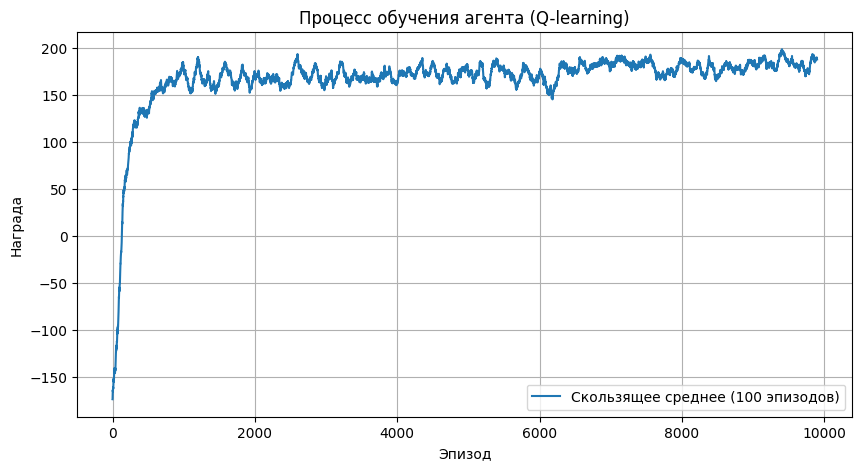

In [6]:
plt.figure(figsize=(10, 5))
window_size = 100
smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
plt.plot(smoothed_rewards, label='Скользящее среднее (100 эпизодов)')
plt.xlabel('Эпизод')
plt.ylabel('Награда')
plt.title('Процесс обучения агента (Q-learning)')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
test_seeds = [12, 103, 256, 777, 1489]
successes = 0

for idx, seed in enumerate(test_seeds):
    print(f"Демонстрация для Seed = {seed} ({idx+1}/{len(test_seeds)})")
    
    state, _ = env.reset(seed=seed)
    terminated, truncated = False, False
    steps = 0
    
    trajectory = []
    actions_names = ['Вперёд', 'Назад', 'Влево', 'Вправо']
    
    while not (terminated or truncated) and steps < 50:
        action = np.argmax(q_table[state])
        img = env.render()
        trajectory.append((img, action, steps + 1))
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        steps += 1
    
    if terminated:
        successes += 1
        status = "ЦЕЛЬ ДОСТИГНУТА!"
    else:
        status = "ВРЕМЯ ВЫШЛО"
    
    print(f"Результат: {status}")
    print(f"Шагов: {steps}")
    
    if len(trajectory) > 0:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.axis('off')
        
        first_img, first_act, first_step = trajectory[0]
        img_display = ax.imshow(first_img)
        title = ax.set_title(f"Seed: {seed} | Шаг {first_step} | Действие: {actions_names[first_act]}", fontsize=10)
        
        def update(frame_idx):
            img, act, step_num = trajectory[frame_idx]
            img_display.set_data(img)
            title.set_text(f"Seed: {seed} | Шаг {step_num} | Действие: {actions_names[act]}")
            return img_display,
        
        ani = animation.FuncAnimation(fig, update, frames=len(trajectory), interval=200, blit=False, repeat=True)
        plt.close()
        display(HTML(ani.to_jshtml()))
        print(f"Анимация для Seed {seed} завершена\n")
    else:
        print(f"Нет кадров для анимации\n")

print(f"ОБЩАЯ СТАТИСТИКА:")
print(f"   Успешно: {successes}/{len(test_seeds)}")
print(f"   Процент успеха: {successes/len(test_seeds)*100:.0f}%")
env.close()

Демонстрация для Seed = 12 (1/5)
Результат: ЦЕЛЬ ДОСТИГНУТА!
Шагов: 11


Анимация для Seed 12 завершена

Демонстрация для Seed = 103 (2/5)
Результат: ЦЕЛЬ ДОСТИГНУТА!
Шагов: 12


Анимация для Seed 103 завершена

Демонстрация для Seed = 256 (3/5)
Результат: ЦЕЛЬ ДОСТИГНУТА!
Шагов: 11


Анимация для Seed 256 завершена

Демонстрация для Seed = 777 (4/5)
Результат: ЦЕЛЬ ДОСТИГНУТА!
Шагов: 5


Анимация для Seed 777 завершена

Демонстрация для Seed = 1489 (5/5)
Результат: ЦЕЛЬ ДОСТИГНУТА!
Шагов: 5


Анимация для Seed 1489 завершена

ОБЩАЯ СТАТИСТИКА:
   Успешно: 5/5
   Процент успеха: 100%
